In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.0566369   7.73020385 11.07420845 13.12309129 17.41456479
 17.57786409 25.51228464 25.51356975 36.14800094 36.14800387]


## Simulaatio

In [4]:
f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7 #Hilbert-avaruuden dimensio

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [5]:
def sim_pulse_2f(f_1,f_2,A,evolution,dim,f_rabi,K=20,t_ramp=10):
    T_floquet = 10*np.pi/(2*f_1-f_2) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on 50 aikapistettä

    N_edge=int(2*t_ramp/dt) #Määritellään reunojen pituudeksi 10 ns (5ns ramppi + 5ns, jotta amplitudi menee lähemmäs nollaa)
    N_pulse=int(1/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_1,f_ef,[pulses.gaussian(2*t_ramp,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,N_pulse,N_edge],time_unit=dt,second_frequency=f_2,drag=True)
    U_floquet=evolution.U_floquet(A*pulse.raw[N_edge:N_edge+K],dt)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge): #Aikakehitys rampille
        psi_eig_accum = evolution_eigenbasis.U(A*pulse.raw[i], dt) @ psi_eig_accum

    #Simuloitujen pulssien määrä, jaetaan kahdellakymmenellä koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (20dt)
    N_sim=int(N_pulse/K)+1

    #Simulaatio pulsseille
    for k in range(0,N_sim):
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        pulse = pulses.Pulse(f_1,f_ef,[pulses.gaussian(t_ramp*2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,K*k,N_edge],time_unit=dt,second_frequency=f_2,drag=True)
        for i in range(0, N_edge): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*pulse.raw[N_edge+K*k+i], dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)
        psi_eig_accum = U_floquet @ psi_eig_accum #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(q,A,evolution,f_rabi,c_guess,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    c_vals=[]
    
    for i in range(min_range, max_range):
        f_1_shifted=f_1*(c_guess+i/scale)
        f_2_shifted=f_2*(c_guess+i/scale)

        c_vals.append(c_guess+i/scale)
        
        delta=q.frequency-2*f_1_shifted+f_2_shifted #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = sim_pulse_2f(f_1_shifted,f_2_shifted,A,evolution,dim,f_rabi,K=200)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=f_q-2f_1+f_2 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    c=c_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(c,pi_pulse,[e_max,f_max],max_e_vals)

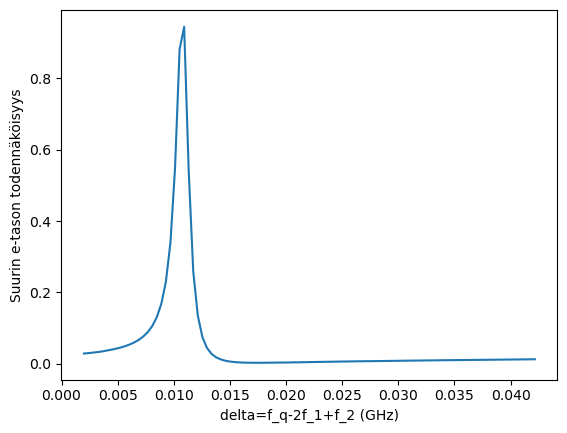

Amplitudi (GHz): 0.2028318451819653
AC-stark siirtymä (GHz): 0.9973074327668577
E-tason suurin todennäköisyys: 0.9448931319703142
Pulssin pituus (ns): 4845.507492432181
Rabi-taajuus (fourier):  9.641122183322991e-05


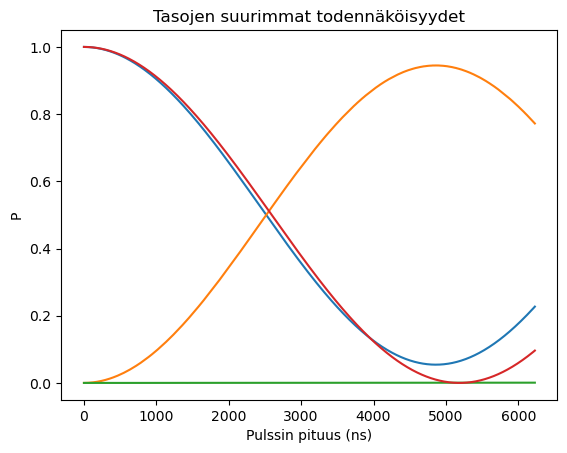

---------------------------------------------


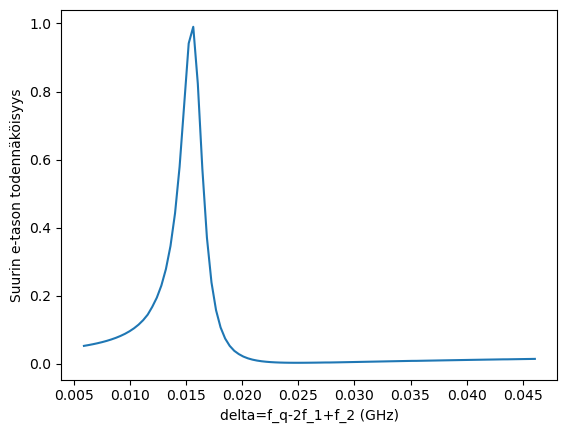

Amplitudi (GHz): 0.24339821421835836
AC-stark siirtymä (GHz): 0.9961428311268886
E-tason suurin todennäköisyys: 0.9902291048211974
Pulssin pituus (ns): 2814.301954015638
Rabi-taajuus (fourier):  0.0001702236048513135


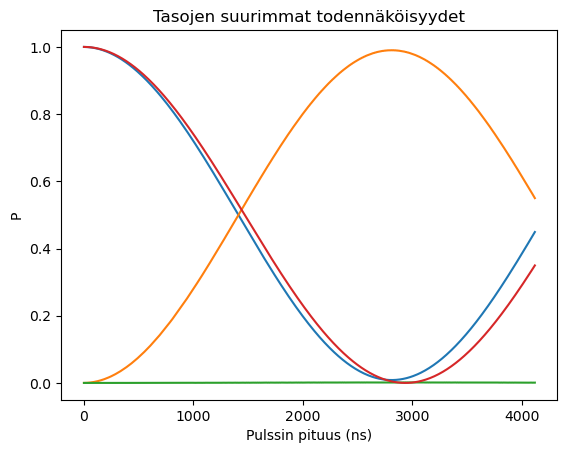

---------------------------------------------


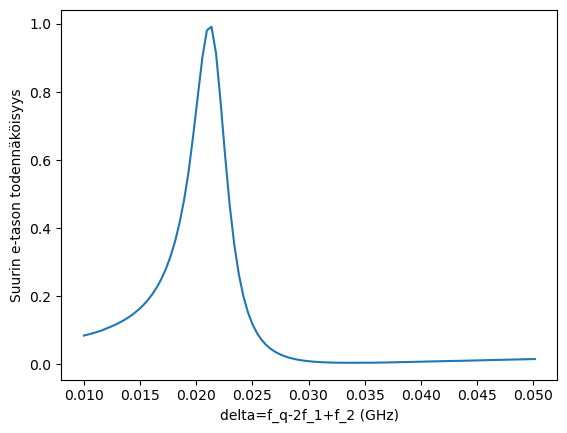

Amplitudi (GHz): 0.28396458325475143
AC-stark siirtymä (GHz): 0.9947362000891394
E-tason suurin todennäköisyys: 0.9919081602990982
Pulssin pituus (ns): 1751.6943562392971
Rabi-taajuus (fourier):  0.0002758382122480945


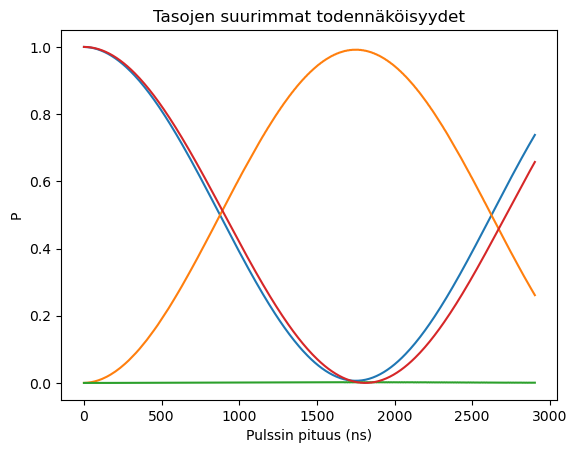

---------------------------------------------


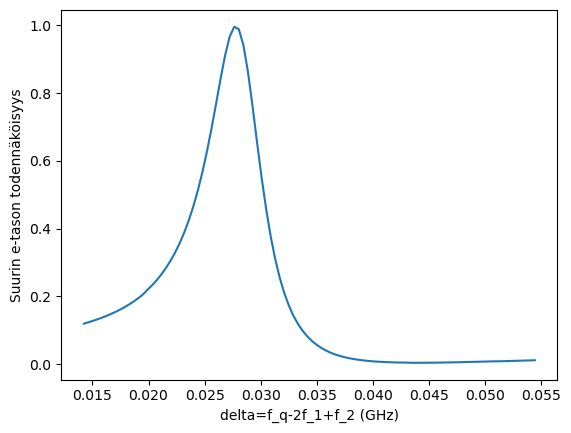

Amplitudi (GHz): 0.3245309522911445
AC-stark siirtymä (GHz): 0.9931875396536101
E-tason suurin todennäköisyys: 0.995867245412401
Pulssin pituus (ns): 1146.224819054663
Rabi-taajuus (fourier):  0.0004310611528107393


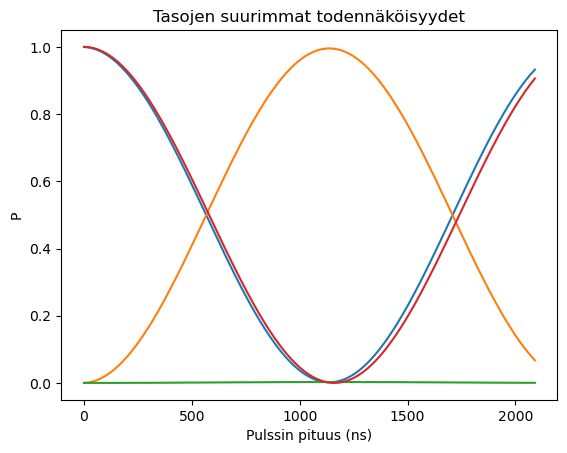

---------------------------------------------


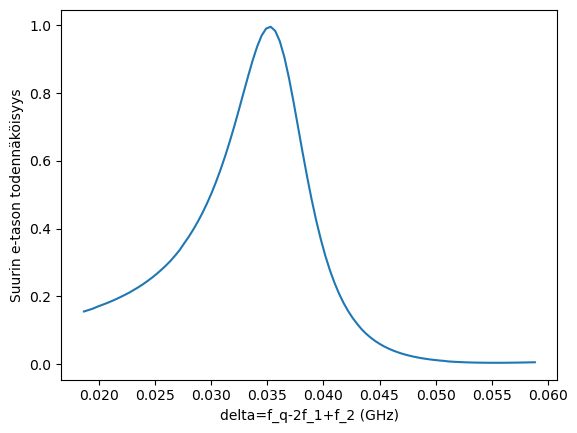

Amplitudi (GHz): 0.3650973213275375
AC-stark siirtymä (GHz): 0.9912968498203004
E-tason suurin todennäköisyys: 0.9965931161904988
Pulssin pituus (ns): 796.8566131743345
Rabi-taajuus (fourier):  0.0006594829576539288


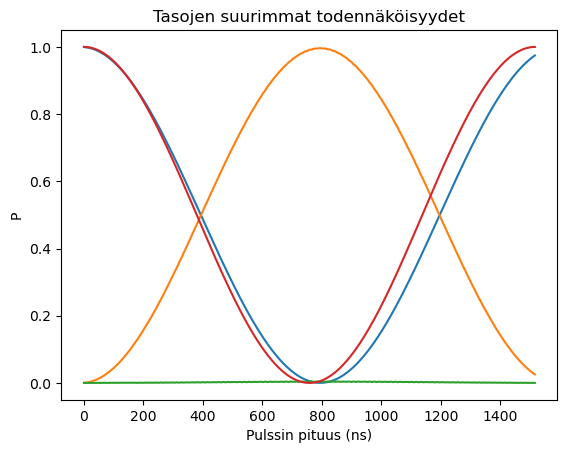

---------------------------------------------


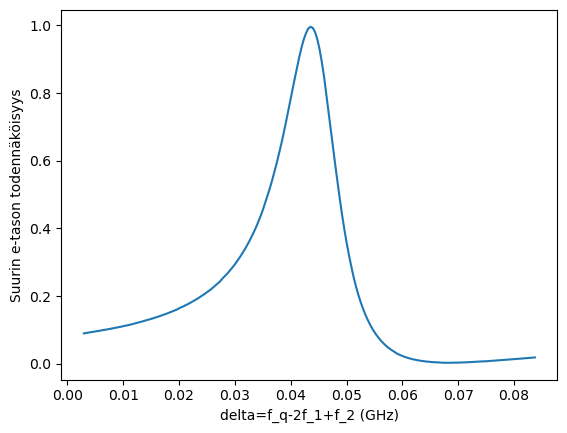

Amplitudi (GHz): 0.4056636903639306
AC-stark siirtymä (GHz): 0.9892641305892106
E-tason suurin todennäköisyys: 0.9958862798027225
Pulssin pituus (ns): 555.814435294657
Rabi-taajuus (fourier):  0.0008992114422607191


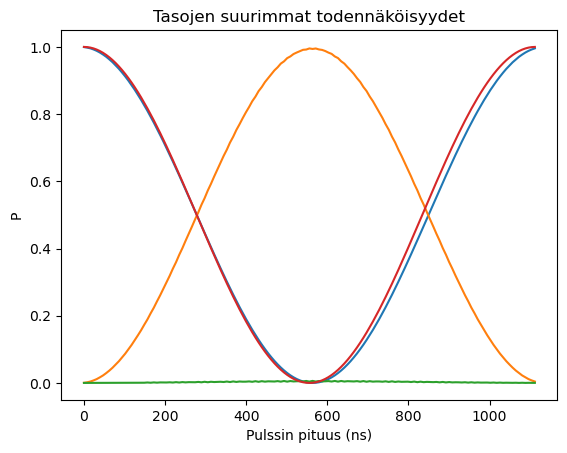

---------------------------------------------


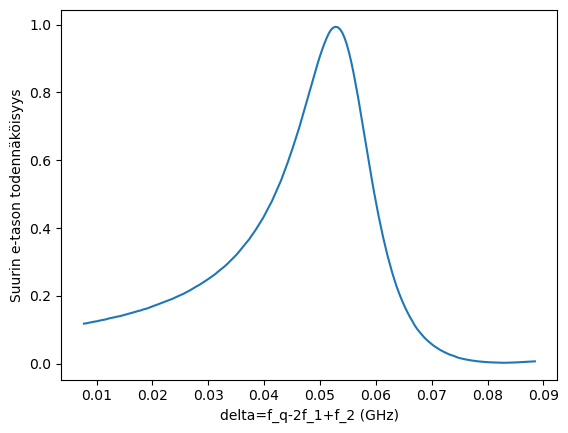

Amplitudi (GHz): 0.4462300594003236
AC-stark siirtymä (GHz): 0.9869893819603406
E-tason suurin todennäköisyys: 0.994644720553679
Pulssin pituus (ns): 415.859976400181
Rabi-taajuus (fourier):  0.0012135973976375868


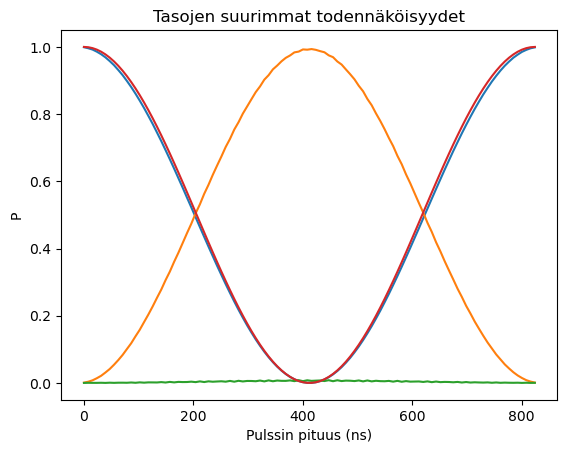

---------------------------------------------


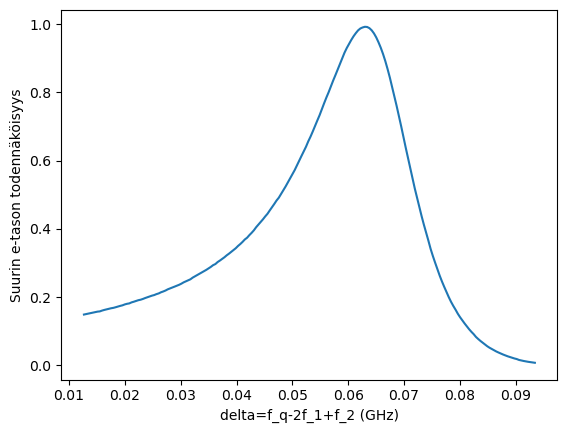

Amplitudi (GHz): 0.4867964284367167
AC-stark siirtymä (GHz): 0.9844726039336905
E-tason suurin todennäköisyys: 0.9930779673372222
Pulssin pituus (ns): 314.6589519763591
Rabi-taajuus (fourier):  0.0016140845388579908


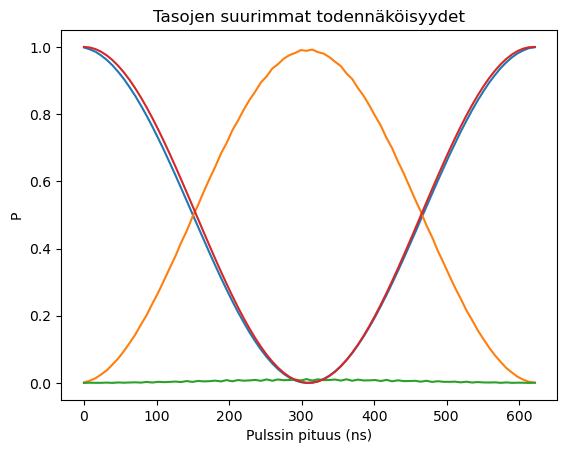

---------------------------------------------


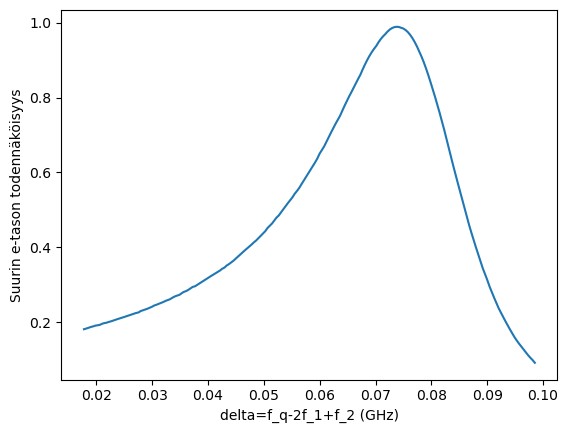

Amplitudi (GHz): 0.5273627974731098
AC-stark siirtymä (GHz): 0.98181379650926
E-tason suurin todennäköisyys: 0.9901012349955408
Pulssin pituus (ns): 228.7455230368733
Rabi-taajuus (fourier):  0.0021168321821088405


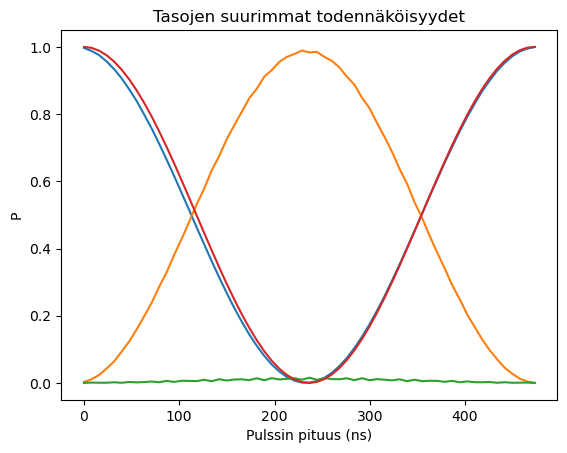

---------------------------------------------


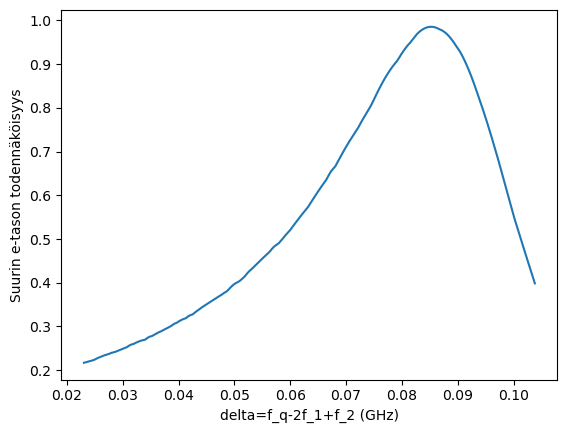

Amplitudi (GHz): 0.5679291665095029
AC-stark siirtymä (GHz): 0.9790129596870495
E-tason suurin todennäköisyys: 0.9873615117634079
Pulssin pituus (ns): 174.02753774191996
Rabi-taajuus (fourier):  0.002735736506538967


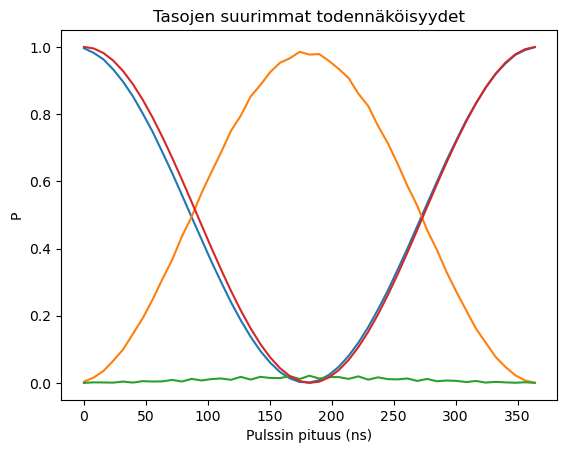

---------------------------------------------


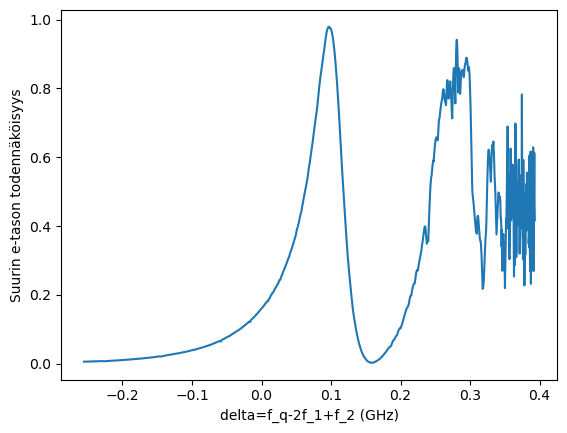

Amplitudi (GHz): 0.608495535545896
AC-stark siirtymä (GHz): 0.9760700934670588
E-tason suurin todennäköisyys: 0.981041778414092
Pulssin pituus (ns): 134.8812712811679
Rabi-taajuus (fourier):  0.0034899125164497098


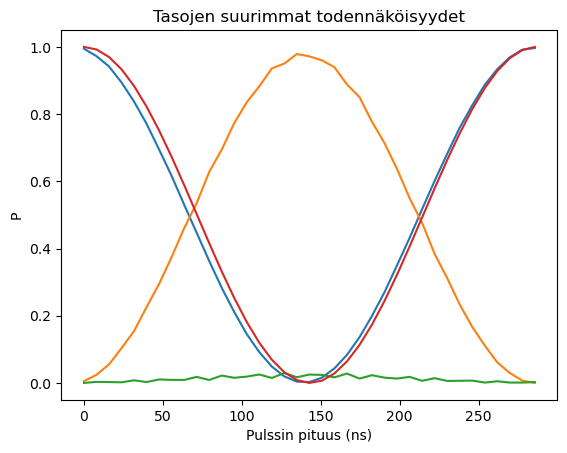

---------------------------------------------


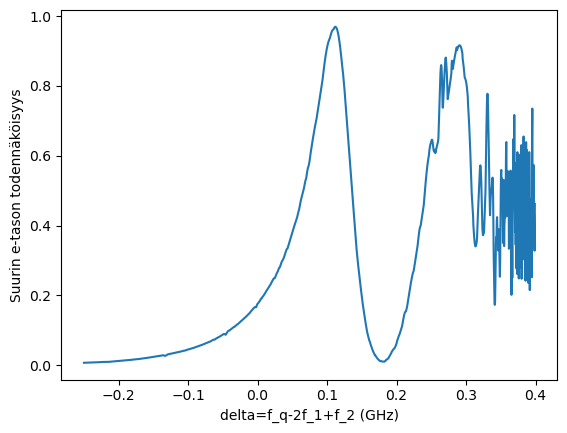

Amplitudi (GHz): 0.649061904582289
AC-stark siirtymä (GHz): 0.9724851978492878
E-tason suurin todennäköisyys: 0.9691107570207782
Pulssin pituus (ns): 119.45160649551342
Rabi-taajuus (fourier):  0.004392066772402696


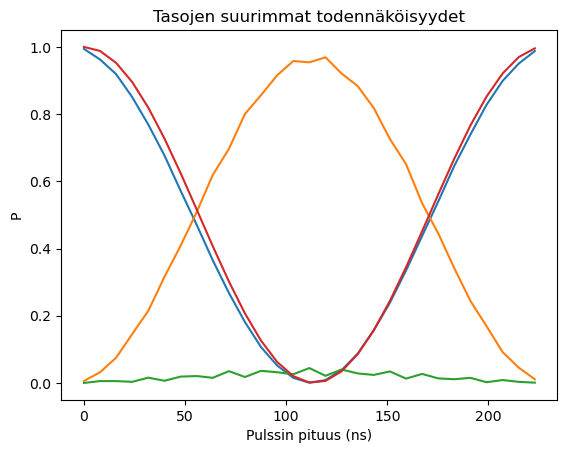

---------------------------------------------


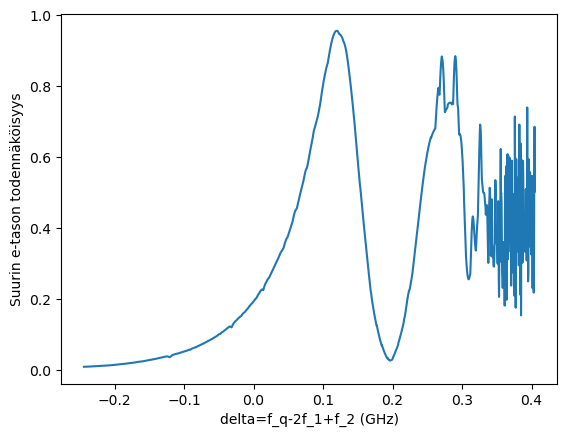

Amplitudi (GHz): 0.689628273618682
AC-stark siirtymä (GHz): 0.9704582728337366
E-tason suurin todennäköisyys: 0.9658760961749605
Pulssin pituus (ns): 79.80073086982794
Rabi-taajuus (fourier):  0.0054483866290565095


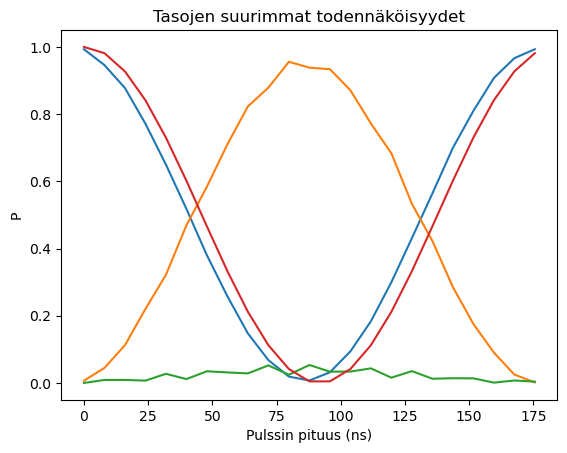

---------------------------------------------


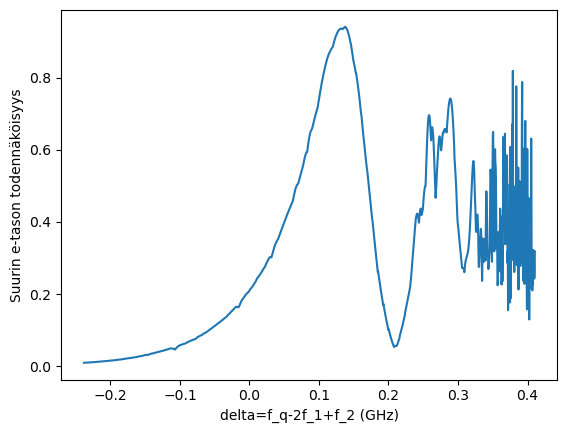

Amplitudi (GHz): 0.730194642655075
AC-stark siirtymä (GHz): 0.9660893184204052
E-tason suurin todennäköisyys: 0.9581736376524131
Pulssin pituus (ns): 80.16161443273789
Rabi-taajuus (fourier):  0.006690505860551256


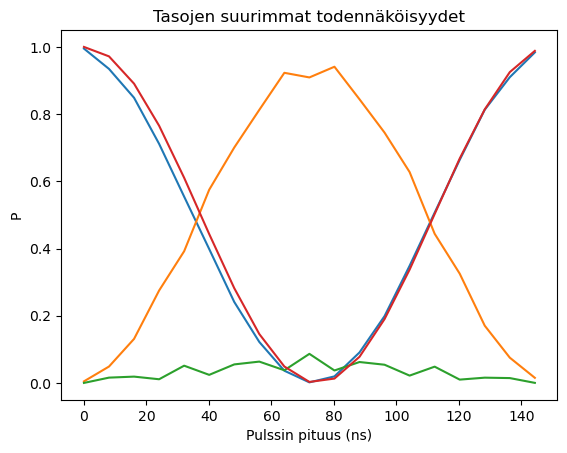

---------------------------------------------


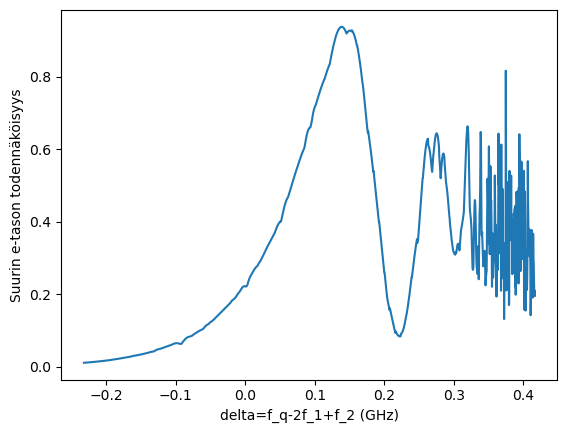

Amplitudi (GHz): 0.770761011691468
AC-stark siirtymä (GHz): 0.9657783346092939
E-tason suurin todennäköisyys: 0.9473469708061556
Pulssin pituus (ns): 56.131198716000355
Rabi-taajuus (fourier):  0.008877464963718948


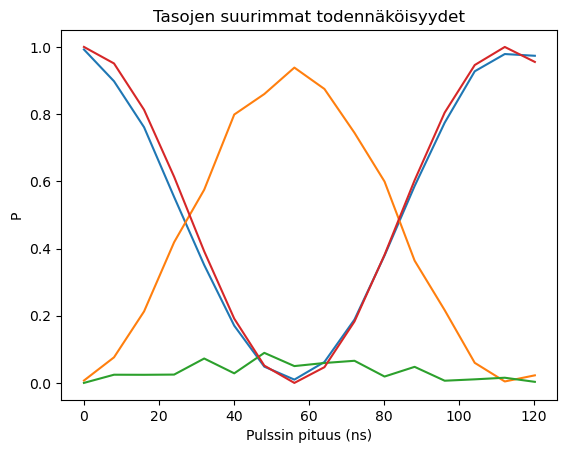

---------------------------------------------


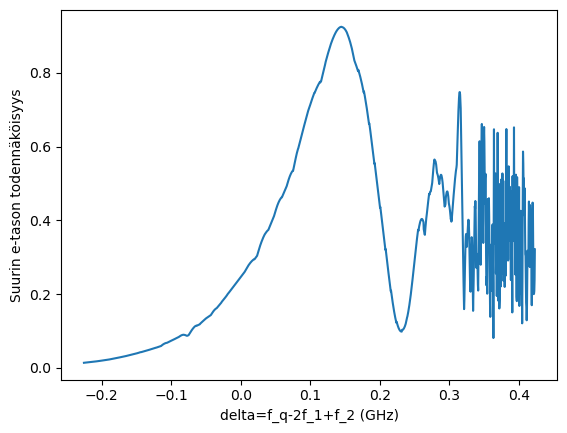

Amplitudi (GHz): 0.8113273807278611
AC-stark siirtymä (GHz): 0.9642253214004022
E-tason suurin todennäköisyys: 0.9409454519258704
Pulssin pituus (ns): 40.158289630025244
Rabi-taajuus (fourier):  0.010679657099210765


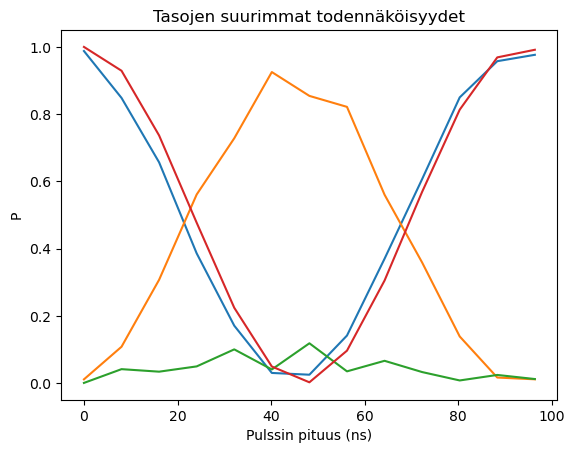

---------------------------------------------


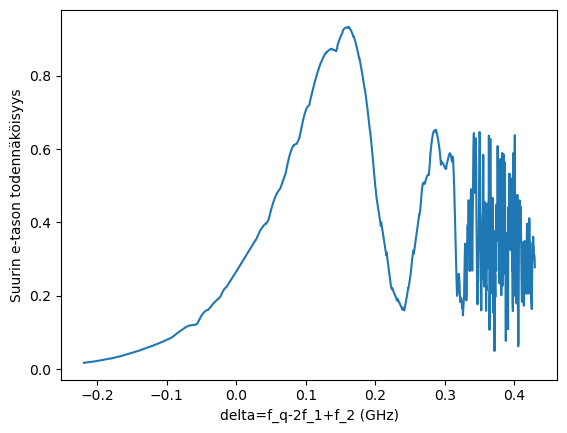

Amplitudi (GHz): 0.8518937497642542
AC-stark siirtymä (GHz): 0.9602302787937301
E-tason suurin todennäköisyys: 0.9427408483885369
Pulssin pituus (ns): 40.325368383555684
Rabi-taajuus (fourier):  0.012682092805312784


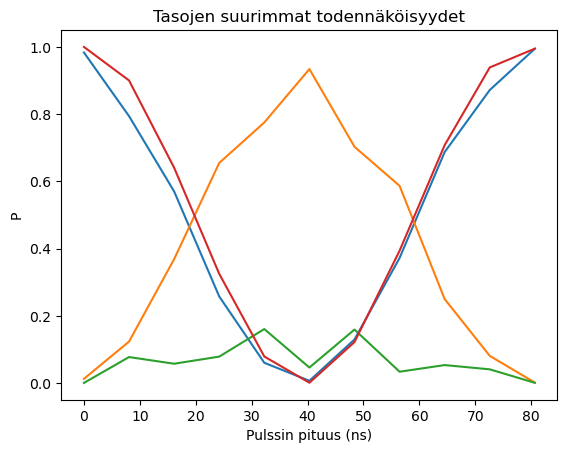

---------------------------------------------


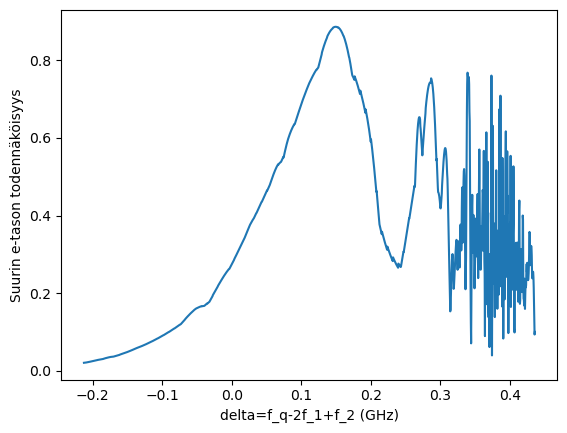

Amplitudi (GHz): 0.8924601188006474
AC-stark siirtymä (GHz): 0.9630932067892781
E-tason suurin todennäköisyys: 0.9300109877471612
Pulssin pituus (ns): 32.16439651110422
Rabi-taajuus (fourier):  0.016140845388579905


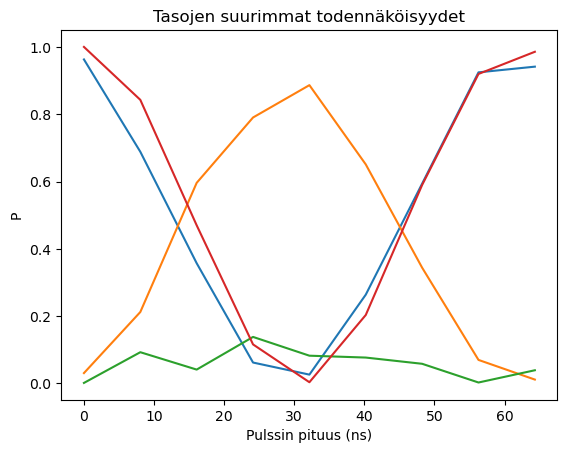

---------------------------------------------


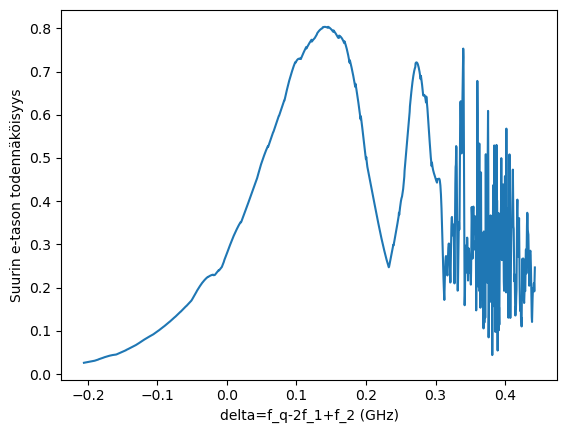

Amplitudi (GHz): 0.9330264878370402
AC-stark siirtymä (GHz): 0.9641141053870458
E-tason suurin todennäköisyys: 0.8916615171120019
Pulssin pituus (ns): 24.0977532694784
Rabi-taajuus (fourier):  0.01889659947931306


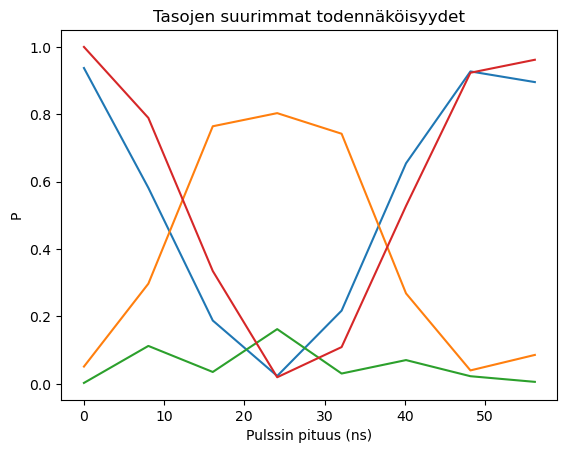

---------------------------------------------


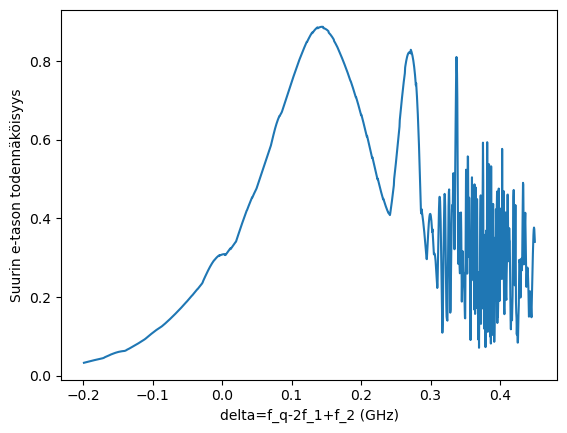

Amplitudi (GHz): 0.9735928568734333
AC-stark siirtymä (GHz): 0.9645929745870334
E-tason suurin todennäköisyys: 0.8872466340449221
Pulssin pituus (ns): 16.057193342914097
Rabi-taajuus (fourier):  0.02182424165216438


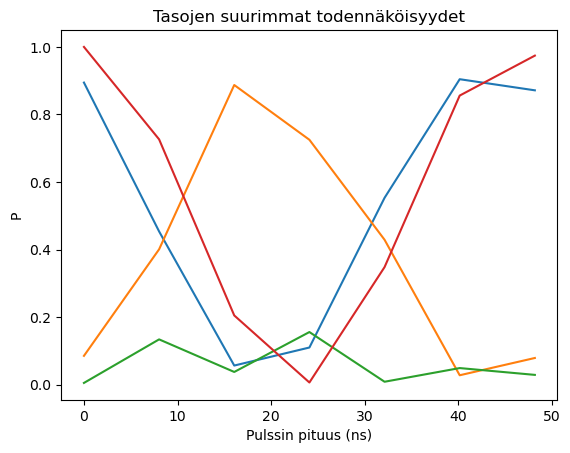

---------------------------------------------


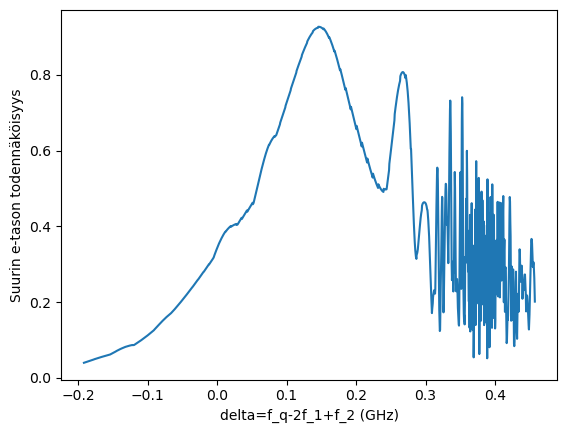

Amplitudi (GHz): 1.0141592259098264
AC-stark siirtymä (GHz): 0.9639298143892407
E-tason suurin todennäköisyys: 0.9269708204620953
Pulssin pituus (ns): 16.068240300228126
Rabi-taajuus (fourier):  0.02540198618530608


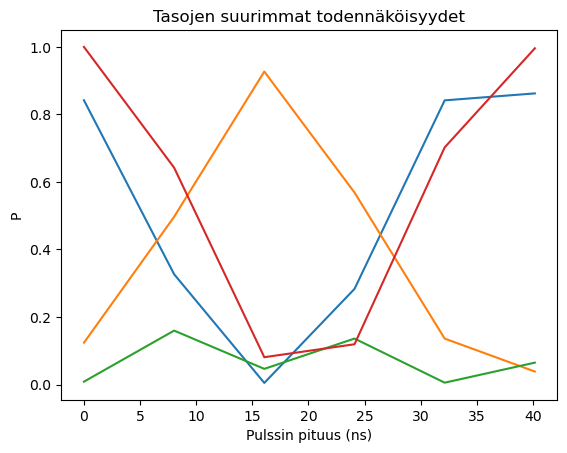

---------------------------------------------


In [6]:
c_vals = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals= []

min_range = 0.05
max_range = 0.25
N_data=21
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)
    f_rabi= 0.03295*A**3 - 0.01835*A**2 + 0.005275*A - 0.0004297 #Arvaus Rabi-taajuudelle
    c=-0.01277*A**2 - 0.01808*A + 0.9988 #Arvaus c:n arvolle
    if i < 5:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi,c,[-50,50],10000)
    elif i < 10:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi,c,[-100,100],10000)
    else:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi,c,[-800,800],10000)
    c_vals.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])

    #Löydetyt optimaaliset ajotaajuudet
    f_1_opt = f_1*c_vals[-1]
    f_2_opt = f_2*c_vals[-1]

    m=10
    vals=sim_pulse_2f(f_1_opt,f_2_opt,A,evolution_eigenbasis,dim,f_rabi/m,K=200)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", c_vals[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    max_vals.append([vals[0],vals[1]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    T_floquet = 10*np.pi/(2*f_1-f_2) #Floquet-jakson pituus
    freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(0.2028318451819653), np.float64(0.24339821421835836), np.float64(0.28396458325475143), np.float64(0.3245309522911445), np.float64(0.3650973213275375), np.float64(0.4056636903639306), np.float64(0.4462300594003236), np.float64(0.4867964284367167), np.float64(0.5273627974731098), np.float64(0.5679291665095029), np.float64(0.608495535545896), np.float64(0.649061904582289), np.float64(0.689628273618682), np.float64(0.730194642655075), np.float64(0.770761011691468), np.float64(0.8113273807278611), np.float64(0.8518937497642542), np.float64(0.8924601188006474), np.float64(0.9330264878370402), np.float64(0.9735928568734333), np.float64(1.0141592259098264)]


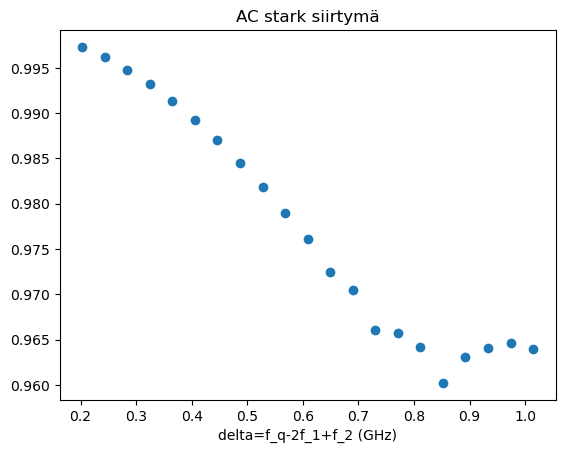

[np.float64(0.9973074327668577), np.float64(0.9961428311268886), np.float64(0.9947362000891394), np.float64(0.9931875396536101), np.float64(0.9912968498203004), np.float64(0.9892641305892106), np.float64(0.9869893819603406), np.float64(0.9844726039336905), np.float64(0.98181379650926), np.float64(0.9790129596870495), np.float64(0.9760700934670588), np.float64(0.9724851978492878), np.float64(0.9704582728337366), np.float64(0.9660893184204052), np.float64(0.9657783346092939), np.float64(0.9642253214004022), np.float64(0.9602302787937301), np.float64(0.9630932067892781), np.float64(0.9641141053870458), np.float64(0.9645929745870334), np.float64(0.9639298143892407)]


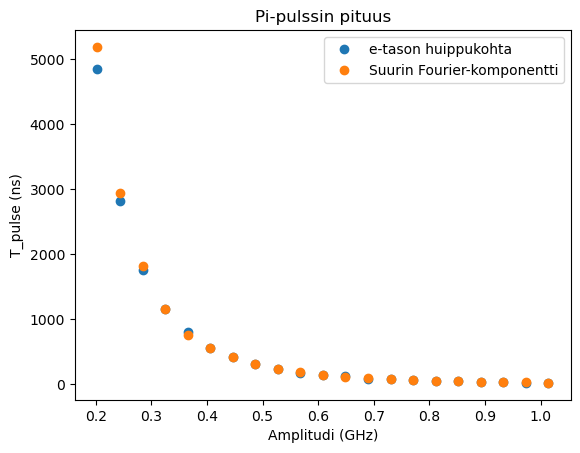

[np.float64(4845.507492432181), np.float64(2814.301954015638), np.float64(1751.6943562392971), np.float64(1146.224819054663), np.float64(796.8566131743345), np.float64(555.814435294657), np.float64(415.859976400181), np.float64(314.6589519763591), np.float64(228.7455230368733), np.float64(174.02753774191996), np.float64(134.8812712811679), np.float64(119.45160649551342), np.float64(79.80073086982794), np.float64(80.16161443273789), np.float64(56.131198716000355), np.float64(40.158289630025244), np.float64(40.325368383555684), np.float64(32.16439651110422), np.float64(24.0977532694784), np.float64(16.057193342914097), np.float64(16.068240300228126)]


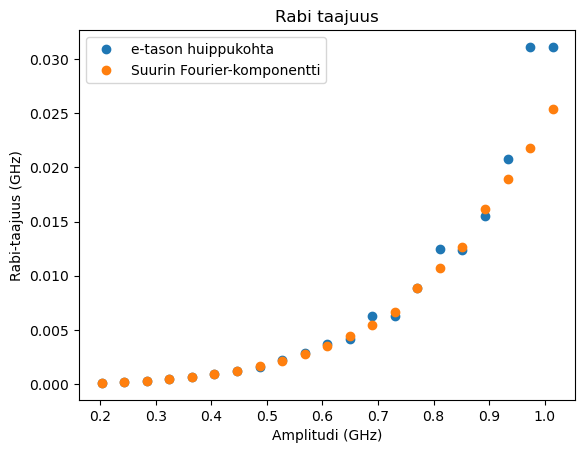

[np.float64(9.641122183322991e-05), np.float64(0.0001702236048513135), np.float64(0.0002758382122480945), np.float64(0.0004310611528107393), np.float64(0.0006594829576539288), np.float64(0.0008992114422607191), np.float64(0.0012135973976375868), np.float64(0.0016140845388579908), np.float64(0.0021168321821088405), np.float64(0.002735736506538967), np.float64(0.0034899125164497098), np.float64(0.004392066772402696), np.float64(0.0054483866290565095), np.float64(0.006690505860551256), np.float64(0.008877464963718948), np.float64(0.010679657099210765), np.float64(0.012682092805312784), np.float64(0.016140845388579905), np.float64(0.01889659947931306), np.float64(0.02182424165216438), np.float64(0.02540198618530608)]


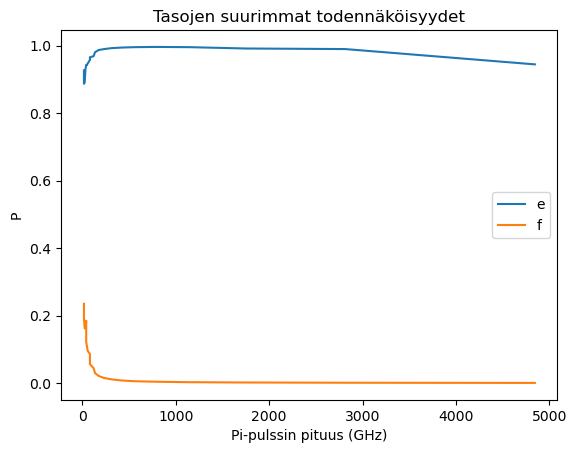

[np.float64(0.9448931319703142), np.float64(0.9902291048211974), np.float64(0.9919081602990982), np.float64(0.995867245412401), np.float64(0.9965931161904988), np.float64(0.9958862798027225), np.float64(0.994644720553679), np.float64(0.9930779673372222), np.float64(0.9901012349955408), np.float64(0.9873615117634079), np.float64(0.981041778414092), np.float64(0.9691107570207782), np.float64(0.9658760961749605), np.float64(0.9581736376524131), np.float64(0.9473469708061556), np.float64(0.9409454519258704), np.float64(0.9427408483885369), np.float64(0.9300109877471612), np.float64(0.8916615171120019), np.float64(0.8872466340449221), np.float64(0.9269708204620953)]
[np.float64(0.0009409924030466707), np.float64(0.0014988830546925596), np.float64(0.0022069820387588895), np.float64(0.0030923390231722575), np.float64(0.0044274785181674355), np.float64(0.005998382535925644), np.float64(0.008242867578036531), np.float64(0.01136559689559182), np.float64(0.015711757888019443), np.float64(0.021612

'\nplt.figure(figsize=(6, 6))\nplt.imshow(data, aspect=\'auto\')  # stretches to square\nplt.colorbar(label="e-tason suurin todennäköisyys")\nplt.show() '

In [7]:
print(A_vals)

plt.figure()
plt.plot(A_vals, c_vals, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=f_q-2f_1+f_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(c_vals)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

"""
plt.figure(figsize=(6, 6))
plt.imshow(data, aspect='auto')  # stretches to square
plt.colorbar(label="e-tason suurin todennäköisyys")
plt.show() """